# Box Plot LST per Klaster (2009–2021)

Notebook ini membuat box plot Land Surface Temperature (LST) per tahun untuk setiap klaster (Klaster 1–4),
mengikuti gaya gambar referensi: 4 subplot (2x2), tiap subplot = 1 klaster, sumbu-x = tahun,
box berwarna berbeda tiap klaster, dan garis putus-putus hitam menghubungkan rata-rata klaster tiap tahun.

**Sumber data (folder `data`):**
- `cluster_spatial_k4.geojson` → label klaster per grid (`grid_id`, `k-means_cluster`, dst.)
- `LSTPuncakKemarau.geojson` → nilai LST per grid per tahun, kolom: `grid_id`, `period` (tahun), `mean` (nilai LST)


In [7]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# 1. KONFIGURASI PATH
# ==========================================================
DATA_DIR = r"C:\Users\Solideo G. Bangun\uhi-dashboard\data"

CLUSTER_FILE = os.path.join(DATA_DIR, "cluster_spatial_k4.geojson")
LST_FILE = os.path.join(DATA_DIR, "LSTPuncakKemarau.geojson")

# Kolom klaster yang ingin dipakai untuk pengelompokan box plot.
# Pilihan: "k-means_cluster", "dtw_k-means_cluster", "k-shape_cluster"
CLUSTER_COL = "k-means_cluster"

# Tahun yang ingin ditampilkan di sumbu-x
YEARS = [2009, 2012, 2015, 2018, 2021]


In [8]:
# ==========================================================
# 2. LOAD DATA KLASTER
# ==========================================================
gdf_cluster = gpd.read_file(CLUSTER_FILE)
print("Kolom pada file klaster:", list(gdf_cluster.columns))
print("Jumlah grid:", len(gdf_cluster))

df_cluster = gdf_cluster[["grid_id", CLUSTER_COL]].copy()
df_cluster = df_cluster.rename(columns={CLUSTER_COL: "cluster"})
df_cluster.head()


Kolom pada file klaster: ['grid_id', 'k-means_cluster', 'dtw_k-means_cluster', 'k-shape_cluster', 'geometry']
Jumlah grid: 639


,grid_id,cluster
0,93175000687,4
1,93185000687,4
2,93195000687,4
3,93205000687,4
4,93215000687,1


In [9]:
# ==========================================================
# 3. LOAD DATA LST (LSTPuncakKemarau.geojson)
#    Kolom: grid_id, period (tahun), mean (nilai LST) -> sudah format long
# ==========================================================
gdf_lst = gpd.read_file(LST_FILE)
print("Kolom pada file LST:", list(gdf_lst.columns))

df_long = gdf_lst[["grid_id", "period", "mean"]].copy()
df_long = df_long.rename(columns={"period": "tahun", "mean": "LST"})
df_long["tahun"] = df_long["tahun"].astype(int)

df_long = df_long[df_long["tahun"].isin(YEARS)]
print("Tahun yang tersedia:", sorted(df_long['tahun'].unique()))
df_long.head()


Kolom pada file LST: ['id', 'end_month', 'first', 'grid_id', 'mean', 'period', 'start_month', 'geometry']
Tahun yang tersedia: [2009, 2012, 2015, 2018, 2021]


,grid_id,tahun,LST
0,93175000687,2009,37.232520
1,93185000687,2009,37.607294
2,93195000687,2009,37.599023
3,93205000687,2009,37.118608
4,93215000687,2009,36.461000


In [10]:
# ==========================================================
# 4. GABUNGKAN DATA KLASTER + LST BERDASARKAN grid_id
# ==========================================================
df = df_long.merge(df_cluster, on="grid_id", how="inner")
df = df.dropna(subset=["LST", "cluster"])
df["cluster"] = df["cluster"].astype(int)

print("Jumlah baris setelah merge:", len(df))
print("Jumlah grid unik per klaster:")
print(df.groupby("cluster")["grid_id"].nunique())
df.head()


Jumlah baris setelah merge: 3195
Jumlah grid unik per klaster:
cluster
1    129
2    140
3    200
4    170
Name: grid_id, dtype: int64


,grid_id,tahun,LST,cluster
0,93175000687,2009,37.232520,4
1,93185000687,2009,37.607294,4
2,93195000687,2009,37.599023,4
3,93205000687,2009,37.118608,4
4,93215000687,2009,36.461000,1


Gambar tersimpan di: C:\Users\Solideo G. Bangun\uhi-dashboard\data\boxplot_LST_per_klaster.png


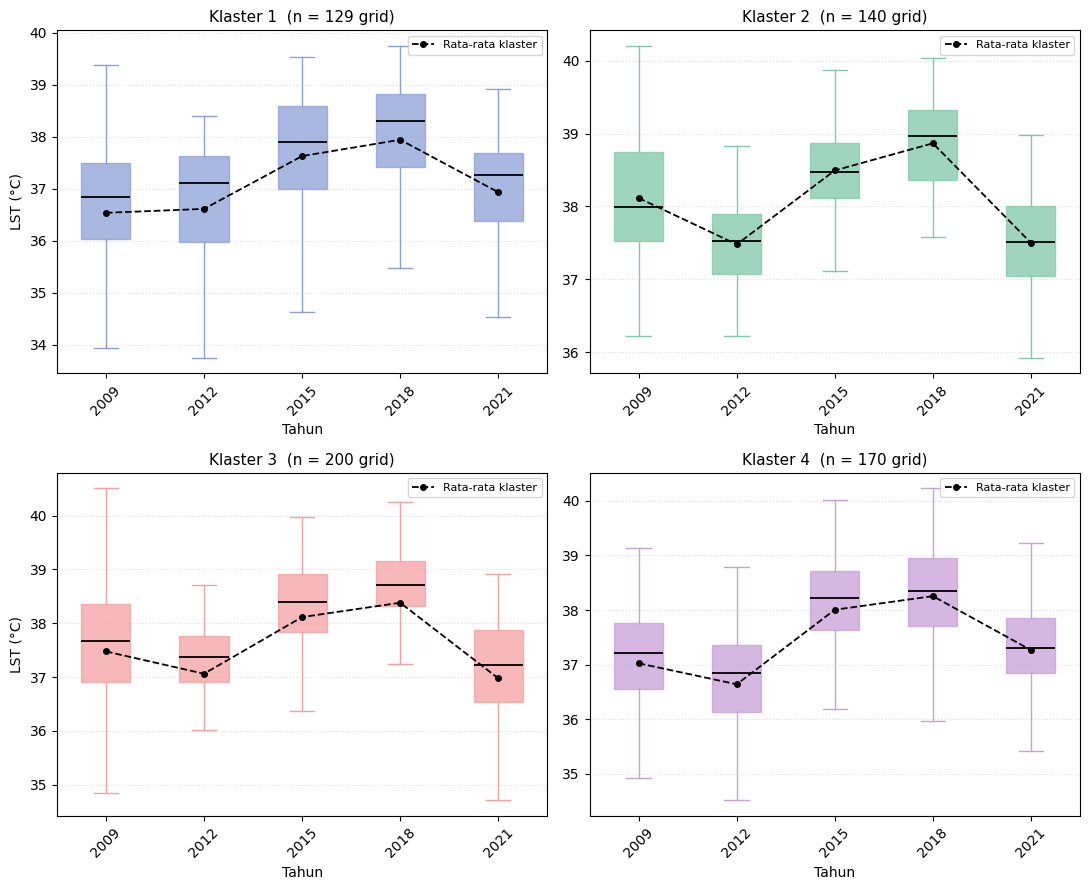

In [11]:
# ==========================================================
# 5. BOX PLOT 2x2 PER KLASTER (meniru gaya gambar referensi)
# ==========================================================
cluster_colors = {
    1: "#8CA0D7",  # biru keunguan
    2: "#7FC8A9",  # hijau toska
    3: "#F4A0A0",  # merah muda salmon
    4: "#C79FD9",  # ungu muda
}

clusters_sorted = sorted(df["cluster"].unique())

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for i, cl in enumerate(clusters_sorted):
    ax = axes[i]
    d = df[df["cluster"] == cl]
    n_grid = d["grid_id"].nunique()

    data_per_tahun = [d.loc[d["tahun"] == y, "LST"].dropna().values for y in YEARS]
    means_per_tahun = [np.mean(vals) if len(vals) else np.nan for vals in data_per_tahun]

    color = cluster_colors.get(cl, "#999999")
    positions = np.arange(1, len(YEARS) + 1)

    bp = ax.boxplot(
        data_per_tahun,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.3),
        boxprops=dict(facecolor=color, edgecolor=color, alpha=0.75),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
    )

    # garis putus-putus rata-rata klaster
    ax.plot(positions, means_per_tahun, linestyle="--", color="black",
            marker="o", markersize=4, linewidth=1.3, label="Rata-rata klaster")

    ax.set_title(f"Klaster {cl}  (n = {n_grid} grid)", fontsize=11)
    ax.set_xticks(positions)
    ax.set_xticklabels(YEARS, rotation=45)
    ax.set_xlabel("Tahun")
    if i % 2 == 0:
        ax.set_ylabel("LST (°C)")
    ax.legend(loc="upper right", fontsize=8, frameon=True)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()

# simpan hasil
OUT_PATH = os.path.join(DATA_DIR, "boxplot_LST_per_klaster.png")
plt.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print("Gambar tersimpan di:", OUT_PATH)

plt.show()


Gambar tersimpan di: C:\Users\Solideo G. Bangun\uhi-dashboard\data\boxplot_LST_per_klaster.png


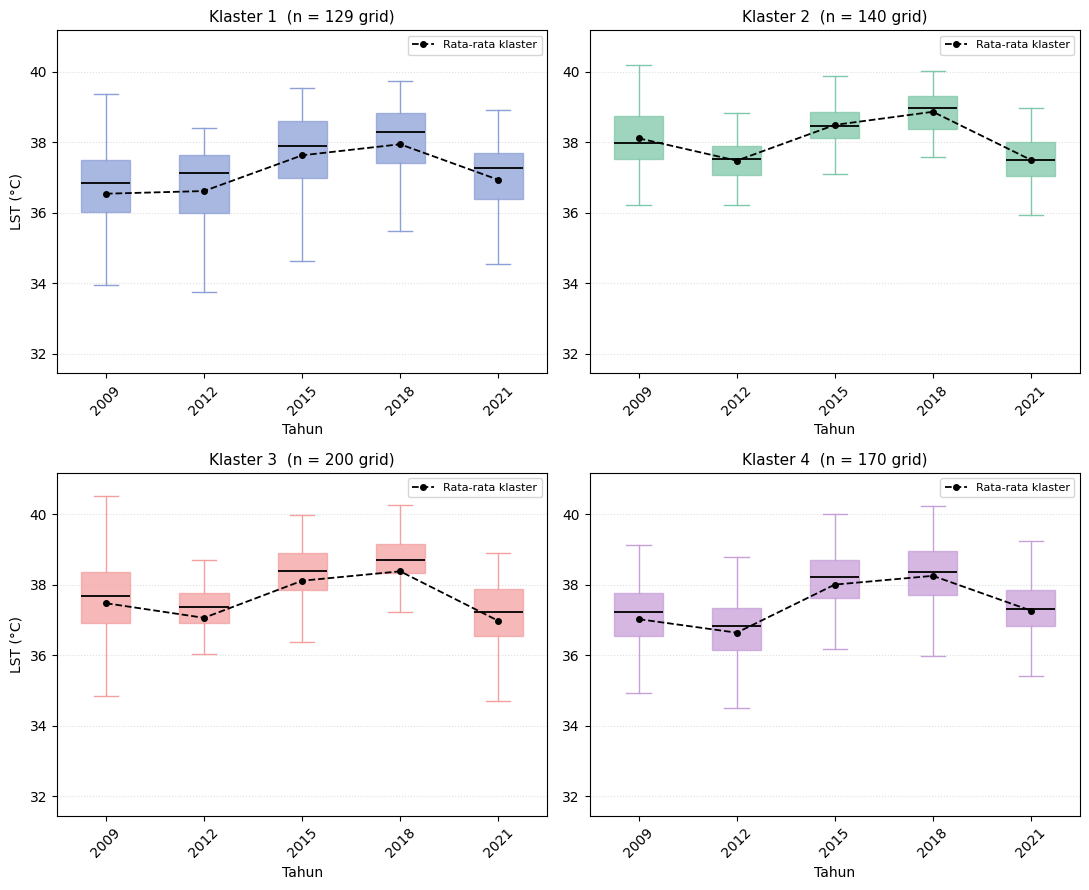

In [12]:
# ==========================================================
# 5. BOX PLOT 2x2 PER KLASTER (meniru gaya gambar referensi)
# ==========================================================
cluster_colors = {
    1: "#8CA0D7",  # biru keunguan
    2: "#7FC8A9",  # hijau toska
    3: "#F4A0A0",  # merah muda salmon
    4: "#C79FD9",  # ungu muda
}

clusters_sorted = sorted(df["cluster"].unique())

# --- TAMBAHAN: hitung skala y GLOBAL supaya semua subplot sama ---
y_min = df["LST"].min()
y_max = df["LST"].max()
y_margin = (y_max - y_min) * 0.08   # padding 8% biar box tidak mepet tepi
Y_LIM = (y_min - y_margin, y_max + y_margin)
# -------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharey=True)  # <-- tambahkan sharey=True
axes = axes.flatten()

for i, cl in enumerate(clusters_sorted):
    ax = axes[i]
    d = df[df["cluster"] == cl]
    n_grid = d["grid_id"].nunique()

    data_per_tahun = [d.loc[d["tahun"] == y, "LST"].dropna().values for y in YEARS]
    means_per_tahun = [np.mean(vals) if len(vals) else np.nan for vals in data_per_tahun]

    color = cluster_colors.get(cl, "#999999")
    positions = np.arange(1, len(YEARS) + 1)

    bp = ax.boxplot(
        data_per_tahun,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.3),
        boxprops=dict(facecolor=color, edgecolor=color, alpha=0.75),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
    )

    ax.plot(positions, means_per_tahun, linestyle="--", color="black",
            marker="o", markersize=4, linewidth=1.3, label="Rata-rata klaster")

    ax.set_title(f"Klaster {cl}  (n = {n_grid} grid)", fontsize=11)
    ax.set_xticks(positions)
    ax.set_xticklabels(YEARS, rotation=45)
    ax.set_xlabel("Tahun")
    ax.set_ylim(Y_LIM)          # <-- TAMBAHAN: kunci skala y sama untuk semua subplot
    ax.tick_params(labelleft=True)  # <-- pastikan angka y tetap tampil di semua subplot
    if i % 2 == 0:
        ax.set_ylabel("LST (°C)")
    ax.legend(loc="upper right", fontsize=8, frameon=True)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()

OUT_PATH = os.path.join(DATA_DIR, "boxplot_LST_per_klaster.png")
plt.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
print("Gambar tersimpan di:", OUT_PATH)

plt.show()

## Catatan

- Jika kolom klaster yang ingin dipakai bukan `k-means_cluster`, ubah `CLUSTER_COL` pada sel konfigurasi (sel 1)
  menjadi `"dtw_k-means_cluster"` atau `"k-shape_cluster"`.
- Outlier disembunyikan (`showfliers=False`) agar tampilan mirip gambar referensi. Set `showfliers=True`
  bila ingin menampilkan titik-titik outlier.
- Palet warna klaster bisa disesuaikan lewat dictionary `cluster_colors`.
- File `LSTPuncakKemarau.geojson` berisi LST musim kemarau (periode `start_month`–`end_month`) per grid per tahun.
  Jika ingin memfilter periode tertentu saja, tambahkan filter pada `gdf_lst` sebelum sel 3, misalnya:
  `gdf_lst = gdf_lst[gdf_lst["start_month"] == 8]`.
